In [2]:
setwd('/home/rstudio/analysis/')

In [3]:
library(Seurat)
library(ggplot2)
library(sctransform)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t




In [4]:
patient3.data <- Read10X(data.dir = "/home/rstudio/run070/run070-nsclc-3_RSEC_MolsPerCell_MEX")
patient3 <- CreateSeuratObject(counts = patient3.data, project = "patient3", min.cells = 3, min.features = 200)

In [5]:
#QC #calculates the percentage of counts originating from a set of features #mitochondrial contamination
patient3[["percent.mt"]] <- PercentageFeatureSet(patient3, pattern = "^MT-")

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


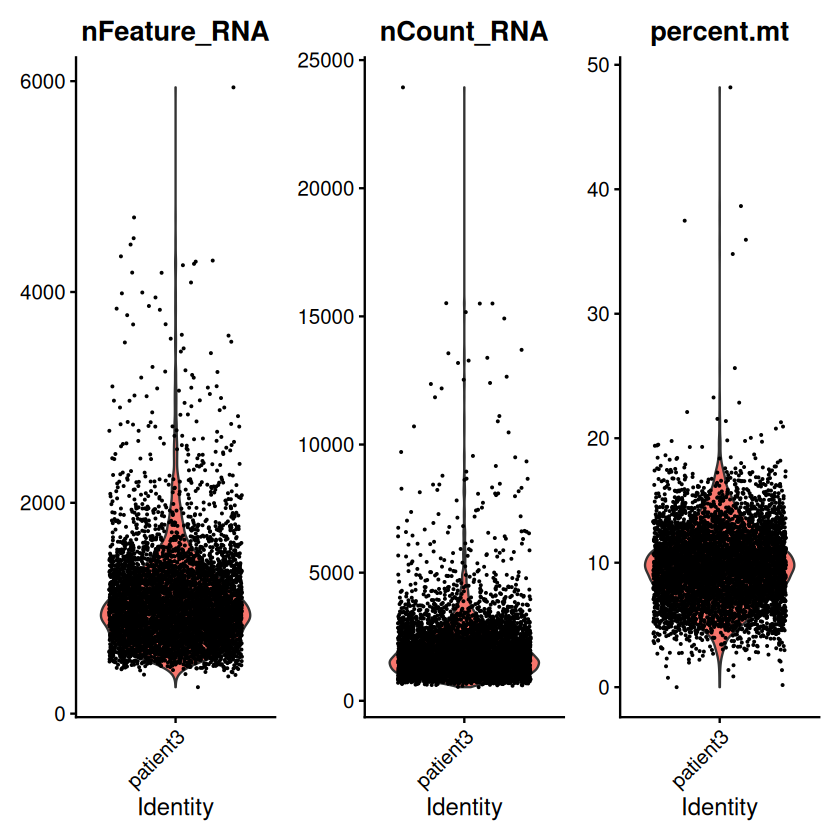

In [6]:
# Violin Plot
VlnPlot(patient3, features = c("nFeature_RNA", "nCount_RNA", "percent.mt"), ncol = 3)

### SCTransform

In [7]:
# run sctransform
# this single command replaces NormalizeData(), ScaleData(), and FindVariableFeatures() #install glmGamPoi
patient3_transform <- SCTransform(patient3, verbose = FALSE) #No filtering based on mito. contamination

In [8]:
#filt mito.
patient3_transform <- subset(patient3_transform, subset = percent.mt < 20) # kept 20 to avoid aggressive filt

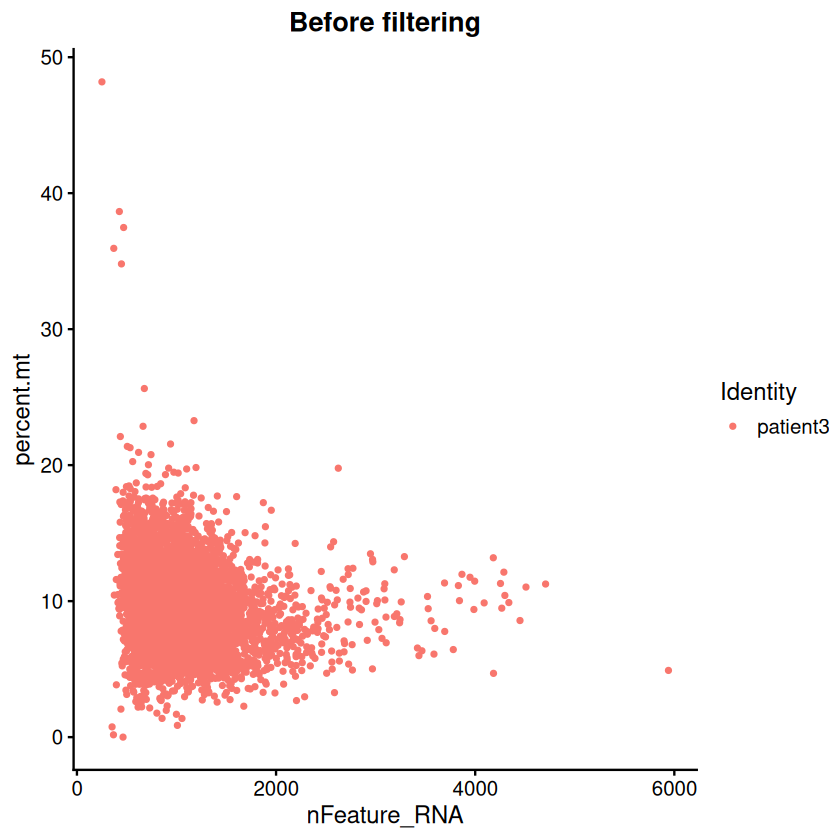

In [9]:
# before filtering
#VlnPlot(patient3, features = c("nFeature_RNA", "percent.mt"), pt.size = 0.1)

FeatureScatter(patient3, feature1 = "nFeature_RNA", feature2 = "percent.mt") +
  ggtitle("Before filtering")

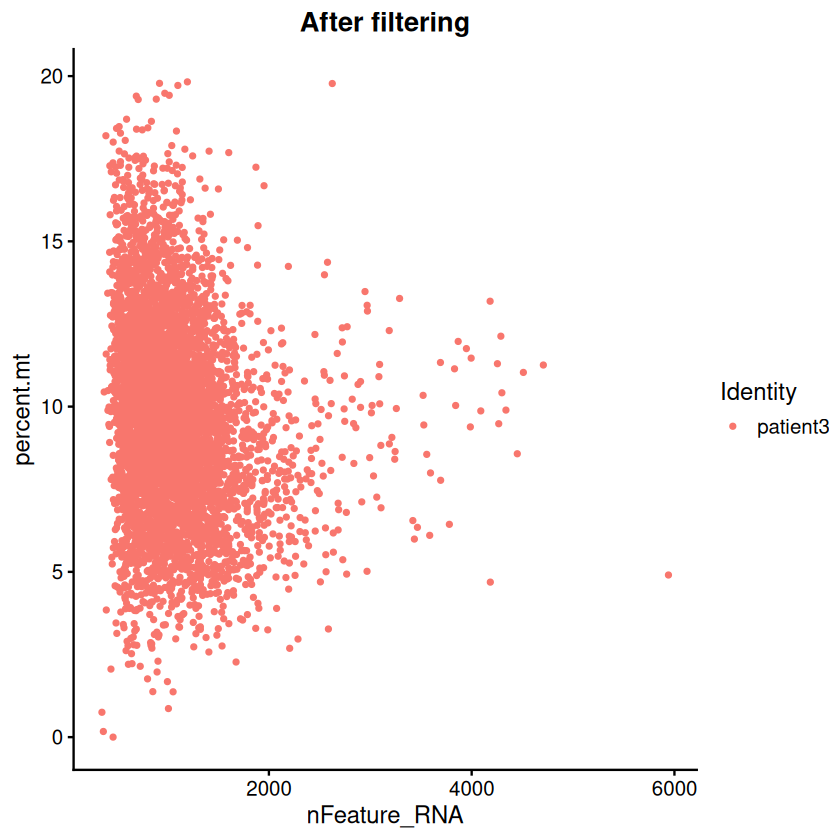

In [10]:
# after filtering
#VlnPlot(patient3_transform, features = c("nFeature_RNA", "percent.mt"), pt.size = 0.1)

FeatureScatter(patient3_transform, feature1 = "nFeature_RNA", feature2 = "percent.mt") +
  ggtitle("After filtering")

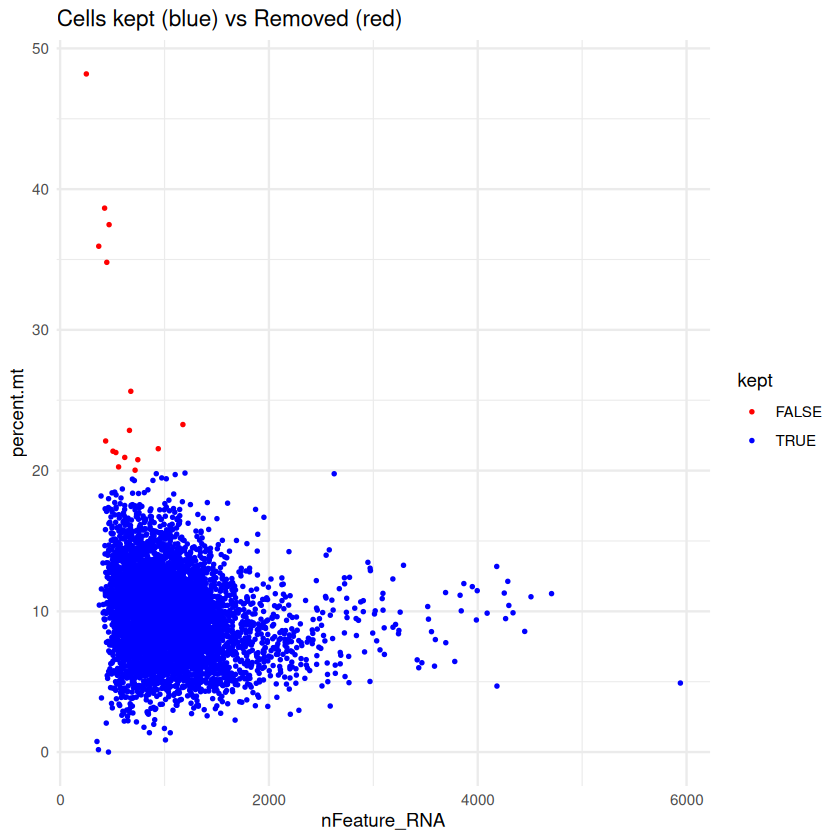

In [11]:
# Retained - Blue, Removed - Red
df <- FetchData(patient3, vars = c("nFeature_RNA", "percent.mt"))
df$kept <- rownames(df) %in% colnames(patient3_transform)

ggplot(df, aes(x = nFeature_RNA, y = percent.mt, color = kept)) +
  geom_point(size = 0.5) +
  scale_color_manual(values = c("red", "blue")) +
  theme_minimal() +
  labs(title = "Cells kept (blue) vs Removed (red)")

### PCA, UMAP, Shared nearest neighbour, Clustering

In [12]:
patient3_transform <- RunPCA(patient3_transform)
patient3_transform <- RunUMAP(patient3_transform, dims = 1:30)
patient3_transform <- FindNeighbors(patient3_transform, dims = 1:30)
patient3_transform <- FindClusters(patient3_transform, resolution = 0.5)

PC_ 1 
Positive:  DUSP4, HSPA1A, CXCL13, HLA-DRB1, CCL5, CD74, HSP90AA1, RBPJ, RGS1, PMAIP1 
	   CRTAM, MYO7A, GZMB, NKG7, CCL4, HLA-DRA, HSPA1B, PRDM1, ITGAE, CBLB 
	   TNFRSF9, VCAM1, GLCCI1, KRT86, CTLA4, HLA-DRB6, LYST, TUBB, TOX, IKZF3 
Negative:  FTH1, EEF1A1, IL7R, PABPC1, RPL34, RPS6, TPT1, RPS18, RPS12, SELL 
	   RPL21, RPS27, RPS3A, RPL3, RPL32, RPS29, RPS13, ANXA1, RPS8, RPS20 
	   RPL39, RPS23, KLF2, RPL13A, RPS27A, RPL9, RPL31, MT-ND2, RPL10, RPS4X 
PC_ 2 
Positive:  MALAT1, TALAM1, LINC-PINT, FYN, ATP1B3, CCL5, AOAH, CBLB, PDE3B, RNF19A 
	   CNOT6L, MAF, SYTL3, TSPYL2, CREM, CEMIP2, PPP1R16B, ATXN1, BTG1, AUTS2 
	   LYST, PARP8, RALGAPA1, PIK3R1, SIK3, AKNA, GFPT2, PTPN22, CST7, PYHIN1 
Negative:  TUBB, TYMS, STMN1, RRM2, HMGN2, ACTB, TUBA1B, MKI67, TOP2A, HMGB2 
	   VIM, ACTG1, ASPM, SMC4, NCAPG, CENPU, CCNA2, PCNA, DUT, HLA-DRA 
	   ANP32B, TMPO, PFN1, HMGB1, CFL1, CENPF, HLA-DRB1, SMC2, CENPE, H2AZ1 
PC_ 3 
Positive:  CXCL13, SESN3, LNCRNA-IUR, SNX9, SELL, RBPJ, PDE3B,

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 5739
Number of edges: 226766

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8393
Number of communities: 8
Elapsed time: 0 seconds


In [13]:
#checking metadata
colnames(patient3_transform@meta.data)

[1] "orig.ident"      "nCount_RNA"      "nFeature_RNA"    "percent.mt"     
[5] "nCount_SCT"      "nFeature_SCT"    "SCT_snn_res.0.5" "seurat_clusters"

## scRepertoire on patient 3

In [14]:
library(scRepertoire)
S1 <- read.delim("/home/rstudio/run070/run070-nsclc-3_VDJ_Dominant_Contigs_AIRR.tsv", sep = "\t", header = TRUE, stringsAsFactors = FALSE)

contig_list_1 <- list(S1)
contig_list_1 <- loadContigs(input = S1, 
                           format = "AIRR")

#converting columns in TCR data to character (string).
contig_list <- lapply(contig_list, function(df) {
  for (col in c("cdr3_nt", "cdr3", "chain", "barcode", "v_gene", "j_gene", "d_gene", "c_gene")) {
    if (col %in% names(df)) df[[col]] <- as.character(df[[col]])
  }
  df
})

In [15]:
#check
#head(contig_list[[1]])

In [16]:
combined.TCR_p3 <- combineTCR(
  contig_list_1,
  samples = c("P3_S1"),
  removeNA = TRUE,
  removeMulti = FALSE,
  filterMulti = FALSE
)

# output = a list of contig data frames that will be reduced to the reads associated with a single cell barcode. It will also combine the multiple reads into clone calls by either the nucleotide sequence (CTnt), amino acid sequence (CTaa), the VDJC gene sequence (CTgene), or the combination of the nucleotide and gene sequence (CTstrict).
#check
head(combined.TCR_p3[[1]])

,barcode,sample,TCR1,cdr3_aa1,cdr3_nt1,TCR2,cdr3_aa2,cdr3_nt2,CTgene,CTnt,CTaa,CTstrict
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,P3_S1_10006345,P3_S1,TRAV35*01.TRAJ18*01.TRAC,CAGPDRGSTLGRLYF,TGTGCTGGACCCGACAGAGGCTCAACCCTGGGGAGGCTATACTTT,TRBV20-1*01.TRBD2*01.TRBJ2-1*01.TRBC2,CSARGLGGSYNEQFF,TGCAGTGCTAGAGGATTGGGGGGGTCCTACAATGAGCAGTTCTTC,TRAV35*01.TRAJ18*01.TRAC_TRBV20-1*01.TRBD2*01.TRBJ2-1*01.TRBC2,TGTGCTGGACCCGACAGAGGCTCAACCCTGGGGAGGCTATACTTT_TGCAGTGCTAGAGGATTGGGGGGGTCCTACAATGAGCAGTTCTTC,CAGPDRGSTLGRLYF_CSARGLGGSYNEQFF,TRAV35*01.TRAJ18*01.TRAC;TGTGCTGGACCCGACAGAGGCTCAACCCTGGGGAGGCTATACTTT_TRBV20-1*01.TRBD2*01.TRBJ2-1*01.TRBC2;TGCAGTGCTAGAGGATTGGGGGGGTCCTACAATGAGCAGTTCTTC
3,P3_S1_10007655,P3_S1,TRAV17*01.TRAJ4*01.TRAC,CATDLFSGGYNKLIF,TGTGCTACGGATCTCTTTTCTGGTGGCTACAATAAGCTGATTTTT,TRBV6-6*01.TRBD2*01.TRBJ2-7*01.TRBC2,CASSQAGEQYF,TGTGCCAGCAGCCAGGCGGGCGAGCAGTACTTC,TRAV17*01.TRAJ4*01.TRAC_TRBV6-6*01.TRBD2*01.TRBJ2-7*01.TRBC2,TGTGCTACGGATCTCTTTTCTGGTGGCTACAATAAGCTGATTTTT_TGTGCCAGCAGCCAGGCGGGCGAGCAGTACTTC,CATDLFSGGYNKLIF_CASSQAGEQYF,TRAV17*01.TRAJ4*01.TRAC;TGTGCTACGGATCTCTTTTCTGGTGGCTACAATAAGCTGATTTTT_TRBV6-6*01.TRBD2*01.TRBJ2-7*01.TRBC2;TGTGCCAGCAGCCAGGCGGGCGAGCAGTACTTC
5,P3_S1_10024172,P3_S1,TRAV12-1*01.TRAJ42*01.TRAC,CVVNLAYYGGSQGNLIF,TGTGTGGTGAACCTTGCTTATTATGGAGGAAGCCAAGGAAATCTCATCTTT,TRBV9*01.NA.TRBJ1-5*01.TRBC1,CASSPGPSQPQHF,TGTGCCAGCAGCCCAGGACCGAGTCAGCCCCAGCATTTT,TRAV12-1*01.TRAJ42*01.TRAC_TRBV9*01.NA.TRBJ1-5*01.TRBC1,TGTGTGGTGAACCTTGCTTATTATGGAGGAAGCCAAGGAAATCTCATCTTT_TGTGCCAGCAGCCCAGGACCGAGTCAGCCCCAGCATTTT,CVVNLAYYGGSQGNLIF_CASSPGPSQPQHF,TRAV12-1*01.TRAJ42*01.TRAC;TGTGTGGTGAACCTTGCTTATTATGGAGGAAGCCAAGGAAATCTCATCTTT_TRBV9*01.NA.TRBJ1-5*01.TRBC1;TGTGCCAGCAGCCCAGGACCGAGTCAGCCCCAGCATTTT
7,P3_S1_10069653,P3_S1,TRAV3*01.TRAJ34*01.NA;TRGV2*01.TRGJP1*01.NA,CAVRGSIGTDKLIF;CATWDGFGWFKIF,TGTGCTGTGAGAGGTTCAATAGGAACCGACAAGCTCATCTTT;TGTGCCACCTGGGACGGGTTCGGTTGGTTCAAGATATTT,TRDV3*01.TRDD3*01.TRDJ1*01.TRDC,CAFNRNWGIHSDKLIF,TGTGCCTTTAATCGAAACTGGGGGATACATTCCGATAAACTCATCTTT,TRAV3*01.TRAJ34*01.NA;TRGV2*01.TRGJP1*01.NA_TRDV3*01.TRDD3*01.TRDJ1*01.TRDC,TGTGCTGTGAGAGGTTCAATAGGAACCGACAAGCTCATCTTT;TGTGCCACCTGGGACGGGTTCGGTTGGTTCAAGATATTT_TGTGCCTTTAATCGAAACTGGGGGATACATTCCGATAAACTCATCTTT,CAVRGSIGTDKLIF;CATWDGFGWFKIF_CAFNRNWGIHSDKLIF,TRAV3*01.TRAJ34*01.NA;TRGV2*01.TRGJP1*01.NA;TGTGCTGTGAGAGGTTCAATAGGAACCGACAAGCTCATCTTT;TGTGCCACCTGGGACGGGTTCGGTTGGTTCAAGATATTT_TRDV3*01.TRDD3*01.TRDJ1*01.TRDC;TGTGCCTTTAATCGAAACTGGGGGATACATTCCGATAAACTCATCTTT
10,P3_S1_10075139,P3_S1,TRAV19*01.TRAJ6*01.TRAC,CALSGRSGGSYIPTF,TGTGCTCTGAGTGGTAGATCAGGAGGAAGCTACATACCTACATTT,TRBV7-9*03.NA.TRBJ1-1*01.TRBC1,CASSFADSTTEAFF,TGTGCCAGCAGCTTTGCCGATTCTACCACTGAAGCTTTCTTT,TRAV19*01.TRAJ6*01.TRAC_TRBV7-9*03.NA.TRBJ1-1*01.TRBC1,TGTGCTCTGAGTGGTAGATCAGGAGGAAGCTACATACCTACATTT_TGTGCCAGCAGCTTTGCCGATTCTACCACTGAAGCTTTCTTT,CALSGRSGGSYIPTF_CASSFADSTTEAFF,TRAV19*01.TRAJ6*01.TRAC;TGTGCTCTGAGTGGTAGATCAGGAGGAAGCTACATACCTACATTT_TRBV7-9*03.NA.TRBJ1-1*01.TRBC1;TGTGCCAGCAGCTTTGCCGATTCTACCACTGAAGCTTTCTTT
12,P3_S1_10088479,P3_S1,TRAV13-1*01.TRAJ54*01.TRAC,CAASMVGAQKLVF,TGTGCAGCAAGTATGGTTGGAGCCCAGAAGCTGGTATTT,TRBV28*01.TRBD1*01.TRBJ2-7*01.TRBC2,CASSLSLGASYEQYF,TGTGCCAGCAGTTTATCTTTGGGGGCCTCCTACGAGCAGTACTTC,TRAV13-1*01.TRAJ54*01.TRAC_TRBV28*01.TRBD1*01.TRBJ2-7*01.TRBC2,TGTGCAGCAAGTATGGTTGGAGCCCAGAAGCTGGTATTT_TGTGCCAGCAGTTTATCTTTGGGGGCCTCCTACGAGCAGTACTTC,CAASMVGAQKLVF_CASSLSLGASYEQYF,TRAV13-1*01.TRAJ54*01.TRAC;TGTGCAGCAAGTATGGTTGGAGCCCAGAAGCTGGTATTT_TRBV28*01.TRBD1*01.TRBJ2-7*01.TRBC2;TGTGCCAGCAGTTTATCTTTGGGGGCCTCCTACGAGCAGTACTTC


## combineExpression()

In [17]:
#check
#head(combined.TCR_p3[[1]]$barcode)
#rownames(patient3_transform@meta.data)
## to see if the headers match here

In [18]:
# Matching the barcodes = removing the 'PS'
combined.TCR_p3 <- lapply(combined.TCR_p3, function(x) {
  x$barcode <- gsub("P3_S1_", "", x$barcode)
  return(x)
})

In [19]:
#check again after removing extra letters
head(colnames(patient3_transform@meta.data))
colnames(combined.TCR_p3[[1]])
head(combined.TCR_p3[[1]]$barcode, 10)
barcodes_tcr <- unlist(lapply(combined.TCR_p3, function(x) x$barcode))
head(barcodes_tcr, 10)
barcodes_seurat <- colnames(patient3_transform)
head(barcodes_seurat, 10)

[1] "orig.ident"   "nCount_RNA"   "nFeature_RNA" "percent.mt"   "nCount_SCT"  
[6] "nFeature_SCT"

[1] "barcode"  "sample"   "TCR1"     "cdr3_aa1" "cdr3_nt1" "TCR2"    
 [7] "cdr3_aa2" "cdr3_nt2" "CTgene"   "CTnt"     "CTaa"     "CTstrict"

[1] "10006345" "10007655" "10024172" "10069653" "10075139" "10088479"
 [7] "10094917" "10115275" "10161117" "10181728"

P3_S11     P3_S12     P3_S13     P3_S14     P3_S15     P3_S16     P3_S17 
"10006345" "10007655" "10024172" "10069653" "10075139" "10088479" "10094917" 
    P3_S18     P3_S19    P3_S110 
"10115275" "10161117" "10181728"

[1] "4100"  "4977"  "11356" "21277" "30102" "41586" "41975" "66729" "71338"
[10] "76819"

In [20]:
sce_patient3 <- combineExpression(
  combined.TCR_p3,
  patient3_transform,
  cloneCall = "CTgene",
  group.by = "sample",
  proportion = TRUE,
  cloneSize = c(Single = 1, Small = 5, Medium = 20, Large = 100, Hyperexpanded = 500) # cloneSize doesn't seem to make a difference later downstream
)

In [21]:
# check the res.
sce_patient3
colnames(sce_patient3@meta.data)

An object of class Seurat 
44925 features across 5739 samples within 2 assays 
Active assay: SCT (21234 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: RNA
 2 dimensional reductions calculated: pca, umap

[1] "orig.ident"       "nCount_RNA"       "nFeature_RNA"     "percent.mt"      
 [5] "nCount_SCT"       "nFeature_SCT"     "SCT_snn_res.0.5"  "seurat_clusters" 
 [9] "CTgene"           "CTnt"             "CTaa"             "CTstrict"        
[13] "clonalProportion" "clonalFrequency"  "cloneSize"

In [23]:
#rownames(sce_patient3@meta.data) ## these are the cell ids

In [27]:
setwd('/home/rstudio/analysis/saved_objects_new')
getwd()

#export

saveRDS(patient3, "patient3.rds")
saveRDS(patient3_transform, "patient3_transform.rds")
saveRDS(combined.TCR_p3, "combined_TCR_p3.rds")

In [24]:
# In R:
write.csv(
  data.frame(
    CellID = rownames(sce_patient3@meta.data),   # or rownames(seurat_object@meta.data)
    Cluster = sce_patient3$seurat_clusters # or seurat_object$celltype
  ),
  file = "seurat_clusters_patient3.csv",
  row.names = FALSE
)

In [26]:
head(colnames(sce_patient3))

[1] "4100"  "4977"  "11356" "21277" "30102" "41586"

In [27]:
head(rownames(sce_patient3@meta.data))

[1] "4100"  "4977"  "11356" "21277" "30102" "41586"